#Modelado de Machine learning

In [ ]:
# #importacion de las librerias
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix,f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
import numpy as np
import pandas as pd
import re

RANDOM_STATE = 42

In [ ]:
df = pd.read_csv("techmindv1.csv")
display(df)

,titulo,texto,categoria,fuente,tags,calidad
0,How do you get state in a custom Extractor?,I'm trying to use Axum's custom extractor to i...,Seguridad,stackoverflow,"rust, jwt, rust-axum",1.0
1,FROM WEB DEVELOPMENT TO BI- EP01,From Web Development To Business intelligence\...,Backend,medium,"['Obiee', 'Odi', 'Oracle', 'Java', 'Jee']",NaN
2,pybind11: how to add document the exported mod...,"I have some c++ code, and I successfully expor...",Programación General,stackoverflow,"python, c++, pybind11",0.9
3,Reference elements in matrices in Julia while ...,I have a vector X whose elements are zeros and...,Ciencia de Datos,stackoverflow,"matlab, julia",1.0
4,"The Falcor data model is a graph, and the Grap...",Falcor\n\nOut of the two Falcor was my first l...,Frontend,medium,"['API', 'JavaScript', 'Nodejs', 'React', 'Soft...",NaN
...,...,...,...,...,...,...
36709,Cannot submit login form with Selenium (Python...,I am trying to login to a website using Seleni...,Frontend,stackoverflow,"python, html, selenium-webdriver",1.0
36710,Room with KMM: Unresolved reference 'instantia...,I'm trying to implement Room into my Kotlin Mu...,Mobile,stackoverflow,"android, ios, kotlin, gradle, kotlin-multiplat...",0.9
36711,Things to know — Amazon Aurora DB,Features that are worth exploring\n\nParallel ...,DevOps / Cloud,medium,"['Relational Databases', 'Getting Started', 'T...",NaN
36712,Create Polars DataFrame with Flattened Json File,The problem that I have is trying to read in a...,Programación General,stackoverflow,"rust, rust-polars",1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36714 entries, 0 to 36713
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   titulo     36714 non-null  object 
 1   texto      36714 non-null  object 
 2   categoria  36714 non-null  object 
 3   fuente     36714 non-null  object 
 4   tags       36714 non-null  object 
 5   calidad    25574 non-null  float64
dtypes: float64(1), object(5)
memory usage: 1.7+ MB


In [ ]:
#unificamos a tipo string las columnas
df['titulo'] = df['titulo'].astype('string')
df['texto'] = df['texto'].astype('string')
df['categoria'] = df['categoria'].astype('string')
df['fuente'] = df['fuente'].astype('string')

In [ ]:
#Se crea la funcion limpiar para pode, quitar ciertos caracteres de las columnas que vamos a opcupar
TERMINOS_CORTOS = {'r', 'c', 'go', 'js', 'ts', 'ai', 'ml', 'db', 'ui', 'ux', 'os', 'qa', 'ci', 'cd', 'vm', 'C++', 'C#'}

def limpiar(texto):
    if not isinstance(texto, str):
        return ""

    # Normalización a minúsculas
    texto = texto.lower()

    # Saltos de línea y tabulaciones -> espacio
    texto = re.sub(r'[\n\t\r]+', ' ', texto)

    # Eliminación de URLs en dado caso que existan
    texto = re.sub(r'http\S+|www\.\S+', '', texto)

    # Eliminación de números
    texto = re.sub(r'\d+', ' ', texto)

    # Signos de puntuación y caracteres especiales
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)

    # Colapsar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto)

    # Filtrar tokens muy cortos, salvo términos técnicos conocidos
    palabras = [p for p in texto.split() if len(p) > 2 or p in TERMINOS_CORTOS]

    return " ".join(palabras).strip()

In [ ]:
#Se aplica la funcion a las columnas correspondientes
df['texto_limpio'] = df['texto'].apply(limpiar)
df['titulo_limpio'] = df['titulo'].apply(limpiar)

In [ ]:
#aliminamos los espacios antes de la cadena y despues
df['texto_completo'] = df['texto_limpio'] + ' ' + df['titulo_limpio'].str.strip()


Preparacion de los datos para el entrenamiento

In [ ]:
#Se definen las variables de entrada y salida
X_texto = df['texto_completo']
y = df['categoria']

In [ ]:
#dividimos los datos de entrenamiento
X_train_texto, X_test_texto, y_train, y_test = train_test_split(
    X_texto, y, test_size=0.2, random_state= RANDOM_STATE, stratify=y
)

In [ ]:

print(f'Train: {len(X_train_texto)} | Test: {len(X_test_texto)}')


Train: 29371 | Test: 7343


#Aplicar TF-IDF
###Transformamos el texto plano en una matriz numérica que pondera la importancia de cada palabra.

In [ ]:
# Iniializamos TfidfVectoricer
vector = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2), min_df=3)

In [ ]:
# Transformacion de los datos y entrrenamiento
X_train_tfidf = vector.fit_transform(X_train_texto)
X_test_tfidf = vector.transform(X_test_texto)

In [ ]:
# Dimenciones de las matrices
print(f'Matriz train: {X_train_tfidf.shape}')
print(f'Matriz test: {X_test_tfidf.shape}')

Matriz train: (29371, 5000)
Matriz test: (7343, 5000)


#Entrenar Regresión Logística

In [ ]:
#Entrenamos al modelo, con regresion logistica class_weight nos ayuda a compensar el desbalance de la clase
modelo_lr = LogisticRegression(max_iter = 1000, class_weight='balanced', random_state= RANDOM_STATE)
modelo_lr.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
#Predicciones usando los datos de prueba
y_pred = modelo_lr.predict(X_test_tfidf)



Evaluar NAIVE BAYES como alternativa

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

#Calcular metricas
Regresion Logistica y NAIVE BAYES

In [ ]:

def obtener_metricas(modelo, X_test, y_test, nombre):
  y_pred = modelo.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred, average='weighted')
  rec = recall_score(y_test, y_pred, average='weighted')
  f1 = f1_score(y_test, y_pred, average='weighted')

  print(f'--- MÉTRICAS DE {nombre} ---')
  print(f'Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}\n')
  print(classification_report(y_test, y_pred))
  return y_pred, acc, f1


y_pred_lr, acc_lr, f1_lr = obtener_metricas(
    modelo_lr, X_test_tfidf, y_test, 'REGRESIÓN LOGÍSTICA'
)
y_pred_nb, acc_nb, f1_nb = obtener_metricas(
    nb_model, X_test_tfidf, y_test, 'NAIVE BAYES'
)

--- MÉTRICAS DE REGRESIÓN LOGÍSTICA ---
Accuracy: 0.7535 | Precision: 0.7535 | Recall: 0.7535 | F1-Score: 0.7529

                      precision    recall  f1-score   support

             Backend       0.63      0.60      0.62      1000
      Bases de Datos       0.80      0.89      0.84       828
    Ciencia de Datos       0.80      0.82      0.81      1000
      DevOps / Cloud       0.73      0.69      0.71      1000
            Frontend       0.82      0.80      0.81      1000
              Mobile       0.86      0.82      0.84      1000
Programación General       0.65      0.68      0.66      1000
           Seguridad       0.73      0.77      0.75       515

            accuracy                           0.75      7343
           macro avg       0.75      0.76      0.75      7343
        weighted avg       0.75      0.75      0.75      7343

--- MÉTRICAS DE NAIVE BAYES ---
Accuracy: 0.6964 | Precision: 0.7010 | Recall: 0.6964 | F1-Score: 0.6968

                      precision  

Comparacion de los algoritmos

In [ ]:
df_comparativa = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Naive Bayes'],
    'Accuracy': [acc_lr, acc_nb],
    'F1-Score (Weighted)': [f1_lr, f1_nb],
})

print(df_comparativa)

                Modelo  Accuracy  F1-Score (Weighted)
0  Regresión Logística  0.753507             0.752932
1          Naive Bayes  0.696446             0.696787


Ajustar Hiperparametros (GridSearchCV)

In [ ]:
param_grid = {'C': [0.1, 1.0, 10.0], 'solver': ['lbfgs', 'saga']}

grid_search = GridSearchCV(
    LogisticRegression(
        max_iter=1500, class_weight='balanced', random_state=RANDOM_STATE
    ),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
)

grid_search.fit(X_train_tfidf, y_train)

print(f'\nMejores Hiperparámetros encontrados: {grid_search.best_params_}')
print(f'Mejor Accuracy en validación cruzada: {grid_search.best_score_:.4f}')

# Seleccionar el mejor modelo optimizado
best_model = grid_search.best_estimator_

# Evaluación final del modelo optimizado
y_pred_best, acc_best, f1_best = obtener_metricas(
    best_model, X_test_tfidf, y_test, 'MEJOR MODELO OPTIMIZADO (GridSearch)'
)


Mejores Hiperparámetros encontrados: {'C': 1.0, 'solver': 'saga'}
Mejor Accuracy en validación cruzada: 0.7378
--- MÉTRICAS DE MEJOR MODELO OPTIMIZADO (GridSearch) ---
Accuracy: 0.7521 | Precision: 0.7522 | Recall: 0.7521 | F1-Score: 0.7516

                      precision    recall  f1-score   support

             Backend       0.63      0.60      0.61      1000
      Bases de Datos       0.81      0.88      0.84       828
    Ciencia de Datos       0.80      0.82      0.81      1000
      DevOps / Cloud       0.73      0.69      0.71      1000
            Frontend       0.81      0.79      0.80      1000
              Mobile       0.86      0.82      0.84      1000
Programación General       0.65      0.67      0.66      1000
           Seguridad       0.73      0.78      0.75       515

            accuracy                           0.75      7343
           macro avg       0.75      0.76      0.75      7343
        weighted avg       0.75      0.75      0.75      7343



MATRICES DE CONFUSION

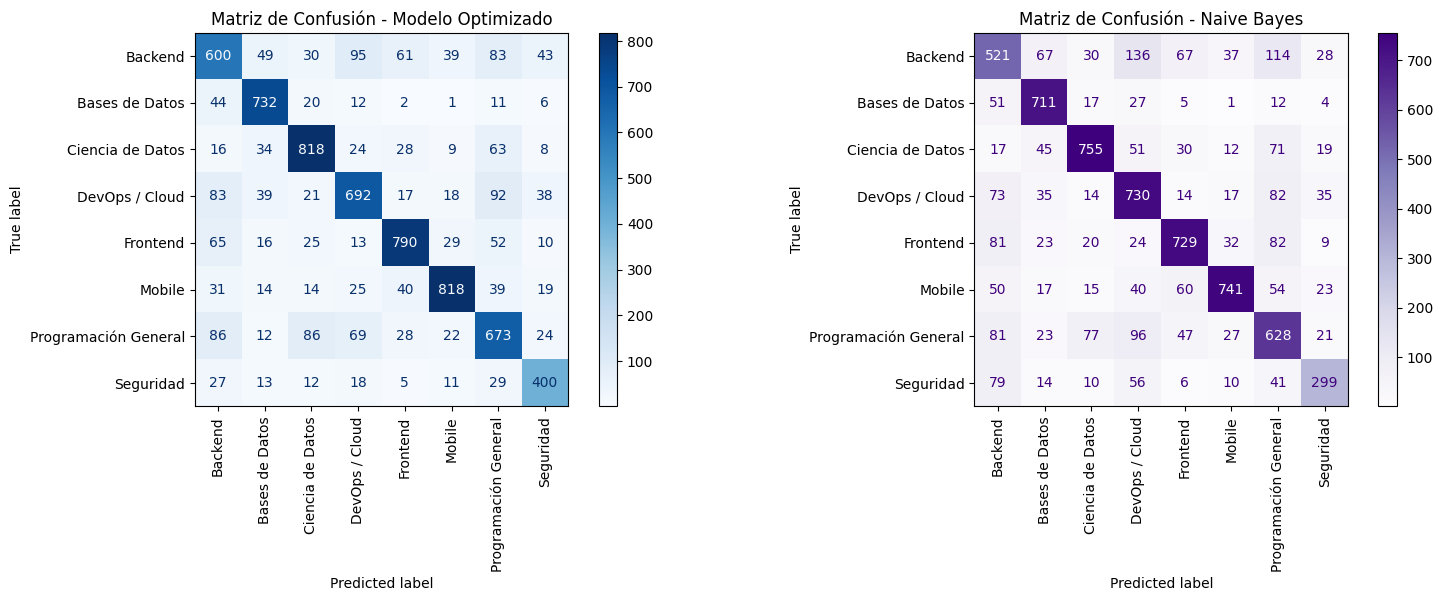

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    ax=axes[0],
    xticks_rotation='vertical',
    cmap='Blues',
)
axes[0].set_title('Matriz de Confusión - Modelo Optimizado')

ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test_tfidf,
    y_test,
    ax=axes[1],
    xticks_rotation='vertical',
    cmap='Purples',
)
axes[1].set_title('Matriz de Confusión - Naive Bayes')

plt.tight_layout()
plt.show()